# 4주차_데이터 탐색과 시각화 Ⅰ

- 탐색적 데이터 분석

---

In [ ]:
# 필요한 패키지 설치

import seaborn as sns             # 데이터 시각화를 위한 seaborn 패키지 임포트
import matplotlib.pyplot as plt   # matplotlib의 시각화 모듈 중 pyplot 서브모듈을 plt로 임포트
import pandas as pd               # 데이터프레임 기반 데이터 분석을 위한 pandas 패키지 임포트

sns.set(color_codes=True)     # seaborn의 시각화 스타일 설정 (색상 코드 사용 가능하게 설정함)
                              # 그래프가 더 세련되고 직관적으로 보이도록 seaborn 전역 설정 적용

# %matplotlib inline       # Jupyter Notebook 환경에서 그래프를 셀 바로 아래에 출력되도록 설정하는 매직 명령어
                        # Python 스크립트(.py)에서는 동작하지 않으며, Notebook 전용 명령어임


In [ ]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
# 데이터 출처는 카글(Kaggle)의 hotel_bookings.csv 파일로, 호텔 예약에 대한 수요 데이터를 포함함

df = pd.read_csv("../../main/datasets/hotel_bookings.csv") 
# pandas의 read_csv 함수를 사용하여 CSV 형식의 데이터를 데이터프레임으로 불러옴
# 상대경로 기준으로 ./datasets 폴더 안의 hotel_bookings.csv 파일을 읽어들임
# 반환된 데이터는 df라는 이름의 pandas DataFrame 객체로 저장됨

# 데이터 샘플 확인
df.head(10)  
# 데이터프레임의 상위 10개 행을 출력하여 전체 데이터 구조를 빠르게 파악하기 위한 명령
# 컬럼 구성, 변수 이름, 각 변수의 데이터 타입 및 예시 값을 확인할 수 있는 중요한 초기 점검 단계


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [6]:
df2 = df[['hotel', 'lead_time']]
# 원본 데이터프레임(df)에서 'hotel'과 'lead_time' 열만 선택하여 새로운 데이터프레임(df2)를 생성함
# 분석 대상이 되는 특정 변수들만 추출하여 가독성과 분석의 초점을 높이기 위한 사전 작업임

df2.head()
# df2 데이터프레임의 상위 5개 행을 출력함
# 열 추출이 제대로 수행되었는지, 데이터 내용이 기대에 부합하는지 확인하기 위한 확인 작업임

,hotel,lead_time
0,Resort Hotel,342
1,Resort Hotel,737
2,Resort Hotel,7
3,Resort Hotel,13
4,Resort Hotel,14


In [ ]:
# 각 컬럼의 속성 및 결측치 확인
df.info()
# 전체 데이터프레임의 컬럼 이름, 데이터 타입, 결측치 개수, 메모리 사용량 등을 요약하여 출력함
# 각 변수의 자료형이 분석 목적에 적합한지, 결측치 처리가 필요한 변수가 무엇인지 확인하는 데 활용됨

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# 각 컬럼의 통계치 확인
df.describe()
# 수치형 변수들에 대한 기초 통계량(평균, 표준편차, 최소값, 4분위수, 최대값 등)을 계산하여 출력함
# 데이터의 분포, 이상치 여부, 스케일 등을 파악하고 이후 정규화 또는 이상치 처리 여부를 판단하는 데 활용됨

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [13]:
# 각 컬럼의 왜도 확인
df.select_dtypes(include='number').skew()
# 수치형 변수들만 선택한 후, 각 변수에 대해 왜도(Skewness)를 계산함
# 왜도는 데이터 분포의 비대칭 정도를 나타내며, 0이면 정규분포에 가까움을 의미함
# 양(+)의 왜도는 오른쪽으로 꼬리가 긴 분포, 음(-)의 왜도는 왼쪽으로 꼬리가 긴 분포를 의미함

is_canceled                        0.536678
lead_time                          1.346550
arrival_date_year                 -0.232583
arrival_date_week_number          -0.010014
arrival_date_day_of_month         -0.002000
stays_in_weekend_nights            1.380046
stays_in_week_nights               2.862249
adults                            18.317805
children                           4.112590
babies                            24.646545
is_repeated_guest                  5.326315
previous_cancellations            24.458049
previous_bookings_not_canceled    23.539800
booking_changes                    6.000270
agent                              1.089386
company                            0.601600
days_in_waiting_list              11.944353
adr                               10.530214
required_car_parking_spaces        4.163233
total_of_special_requests          1.349189
dtype: float64

In [ ]:
# 각 컬럼의 첨도 확인
df.select_dtypes(include='number').kurtosis()
# 수치형 변수들만 선택한 후, 각 변수에 대해 첨도(Kurtosis)를 계산함
# 첨도는 분포의 뾰족한 정도를 나타내며, 값이 클수록 중심에 데이터가 몰려 있고 꼬리가 두꺼움을 의미함
# 정규분포의 첨도는 3이며, 보통 이 기준에서 벗어나는지를 보기 위해 '초과 첨도(excess kurtosis)'를 계산함 
# (pandas는 초과 첨도 기준 사용)

is_canceled                         -1.712005
lead_time                            1.696449
arrival_date_year                   -0.994564
arrival_date_week_number            -0.986077
arrival_date_day_of_month           -1.187168
stays_in_weekend_nights              7.174066
stays_in_week_nights                24.284555
adults                            1352.115116
children                            18.673692
babies                            1633.948235
is_repeated_guest                   26.370077
previous_cancellations             674.073693
previous_bookings_not_canceled     767.245210
booking_changes                     79.393605
agent                               -0.007180
company                             -0.490795
days_in_waiting_list               186.793070
adr                               1013.189851
required_car_parking_spaces         29.998056
total_of_special_requests            1.492565
dtype: float64

/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_88979/3375535148.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['lead_time'])


<Axes: xlabel='lead_time', ylabel='Density'>

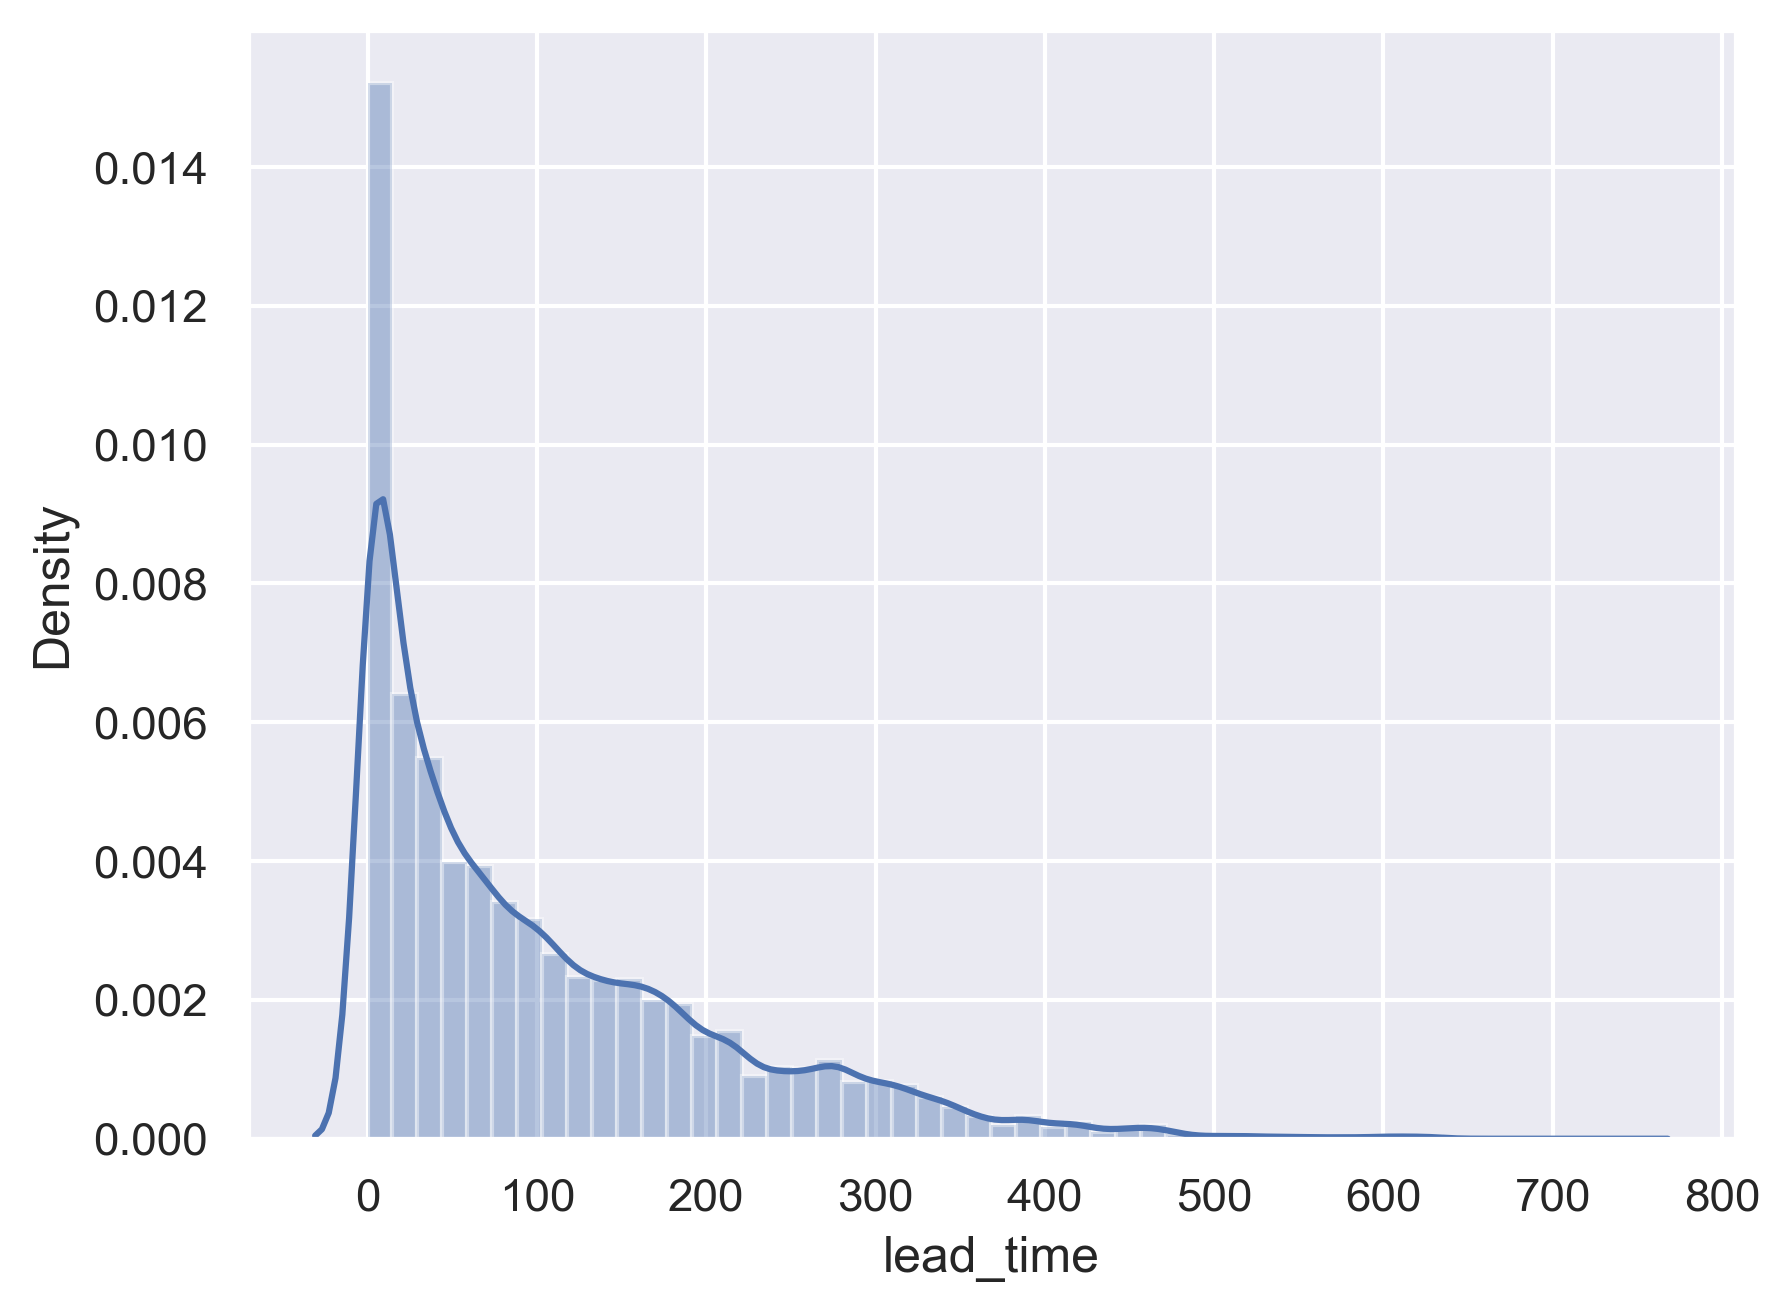

In [14]:
# 특정 변수 분포 시각화
plt.rcParams['figure.dpi'] = 300
# 시각화된 그래프의 해상도를 높이기 위해 DPI(Dots Per Inch)를 300으로 설정함
# 고해상도 그래프를 생성하여 출력 품질을 향상시킴

sns.distplot(df['lead_time'])
# seaborn의 distplot 함수를 사용하여 'lead_time' 변수의 분포를 시각화함
# 히스토그램 + 커널 밀도 추정(KDE)이 함께 출력되어, 데이터 분포의 형태를 직관적으로 파악할 수 있음
# 왜도, 이상치, 분포의 정규성 여부 등을 시각적으로 확인할 수 있는 유용

<Axes: xlabel='hotel', ylabel='lead_time'>

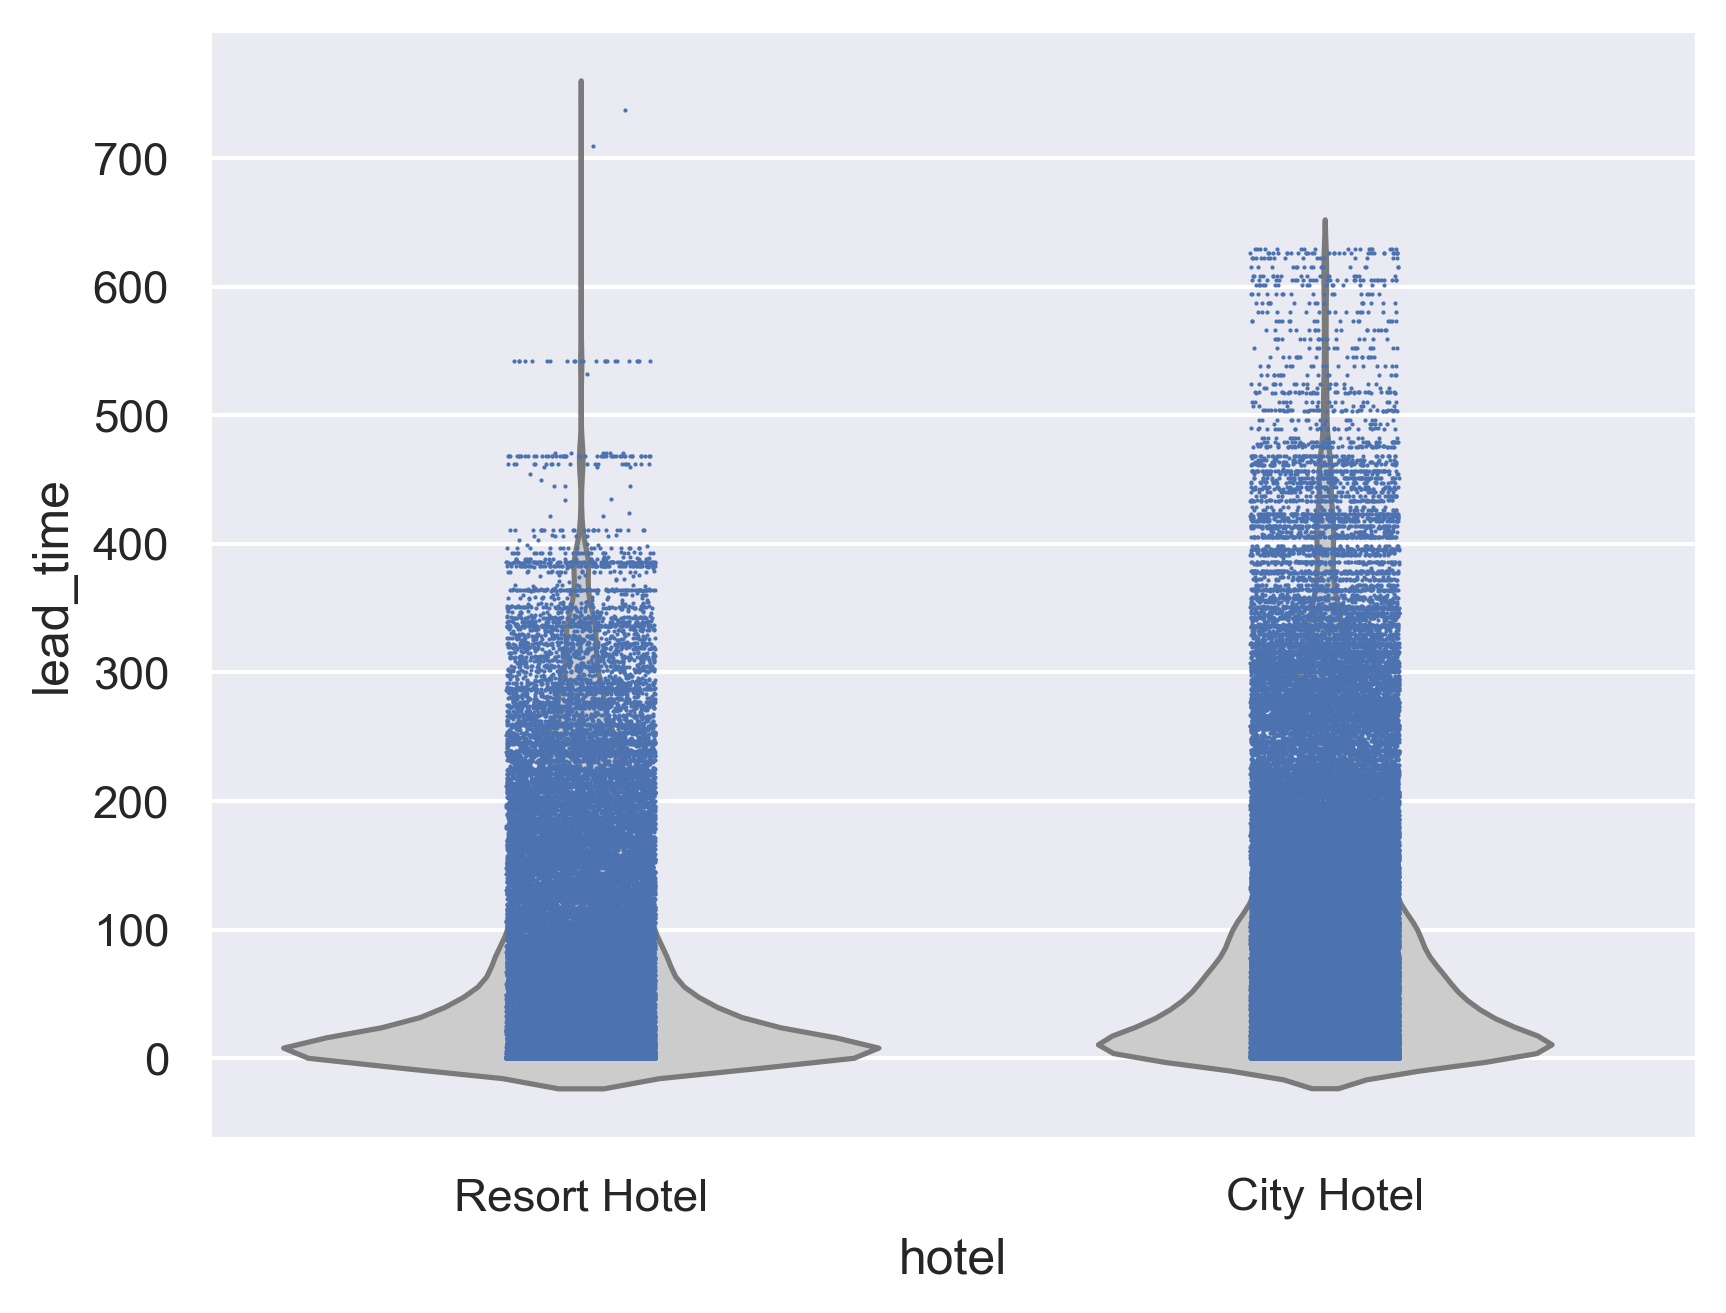

In [ ]:
# 호텔 구분에 따른 lead_time 분포 차이 시각화
sns.violinplot(x="hotel", y="lead_time", data=df, inner=None, color=".8")
# 호텔(hotel) 유형에 따라 예약까지 걸린 일수(lead_time)의 분포 차이를 바이올린플롯으로 시각화함
# 바이올린플롯은 KDE(밀도 추정)를 활용하여 분포의 형태와 폭을 시각적으로 보여주는 그래프임
# inner=None 설정은 중앙의 박스플롯, 중앙값 등을 생략하고 외형 밀도만 시각화함
# color=".8"은 회색 계열의 중간 밝기로 설정하여 배경처럼 표현됨

sns.stripplot(x="hotel", y="lead_time", data=df, size=1)
# 동일한 그래프 위에 각 개별 데이터 포인트를 점 형태로 추가하여 데이터의 실제 분포를 시각화함
# size=1로 설정하여 점 크기를 작게 조정함으로써 데이터 밀집도를 더 정밀하게 표현함
# 바이올린플롯과 스트립플롯을 함께 사용함으로써 전체적인 분포와 개별 샘플의 위치를 동시에 확인할 수 있음